### **Team Members**
- [Member 1 Name]
- [Member 2 Name]
- [Member 3 Name]
- [Member 4 Name]

### **Project Description**
This project predicts student stress levels encoded in **3 distinct binned categories** based on information about various aspects of student life including relationships, finances, student habits, and substance use.

### Problem Statement (Classification)
Predict student stress levels categorized into three distinct classes:
- **Low Stress**: Score range 1-3
- **Average Stress**: Score range 4-6  
- **High Stress**: Score range 7-10

### **Import Libraries**
Import all necessary Python libraries for data processing, machine learning, and visualization.

In [1]:
# Import standard libraries
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


### **Configure Project Paths**
Set up the project directory structure and add paths to Python's module search path for importing backend modules.

In [2]:
project_root = Path.cwd()
if not (project_root / "backend").exists() and project_root.name == "notebooks":
    project_root = project_root.parent

backend_root = project_root / "backend"
for p in (project_root, backend_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("✓ Paths configured")

✓ Paths configured


### **Import Project Modules**
Import custom modules from the backend package including data pipeline, ML utilities, and model classes.

In [3]:
import importlib

from backend import config

import backend.src.models.logistic_regression_model as _lr_mod
import backend.src.models.neural_network_model as _nn_mod
import backend.src.models.gradient_boosting_model as _gb_mod
import backend.src.models.decision_tree_model as _dt_mod
import backend.src.models as _models_pkg

for _mod in (_lr_mod, _nn_mod, _gb_mod, _dt_mod, _models_pkg):
    importlib.reload(_mod)

from backend.src.architecture.data_pipeline import DataLoader, DataCleaner, FeatureEngineer
from backend.src.architecture.ml_utils import Converters, Pipeliner, ProfileGenerator
from backend.src.architecture.ml_tasks import EDA, Evaluator, Predictor
from backend.src.architecture.visualizer import Visualizer
from backend.src.models import LogisticRegressionModel, NeuralNetworkModel, GradientBoostingModel

print("✓ Modules imported successfully")


✓ Modules imported successfully


### **Initialize Pipeline Components**
Create instances of data processing components: loader, cleaner, feature engineer, converters, visualizer, evaluator, pipeliner, predictor, and profile generator.

In [4]:
loader = DataLoader()
cleaner = DataCleaner()
engineer = FeatureEngineer()
converters = Converters()
visualizer = Visualizer()
eda = EDA(visualizer)
evaluator = Evaluator()
pipeliner = Pipeliner(config.ALL_NUMERIC, config.ALL_CATS)
predictor = Predictor()
profile_generator = ProfileGenerator(
    config.NUMERIC_COLS,
    config.CATEGORICAL_COLS,
    config.ALL_NUMERIC,
    config.ALL_CATS,
)

print("✓ Pipeline components initialized")

✓ Pipeline components initialized


### **Initialize Models**
Create instances of three classification models: Logistic Regression, Neural Network, and Gradient Boosting.
1. **Logistic Regression**: Baseline linear model for multi-class classification
2. **Neural Network**: Deep learning approach with multiple hidden layers
3. **Gradient Boosting**: Ensemble method using decision trees

In [5]:
from backend.src.models import DecisionTreeModel

models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    GradientBoostingModel(),
    DecisionTreeModel(),
]

print("✓ Models initialized")
print(f"  → {len(models)} models ready: {[m.get_name() for m in models]}")


✓ Models initialized
  → 4 models ready: ['Multinomial Logistic Regression', 'Neural Network', 'Gradient Boosting', 'Decision Tree']


### **Data Ingestion & Initial Processing**
Loading the raw survey data from CSV file containing student responses. The dataset includes:
- **Numeric features**: age, hours_work, social_media_use, rent, friends_count, etc.
- **Categorical features**: gender, relationship_status, drug_use_ans, student_type, etc.
- **Target variable**: stress (continuous score)

Only students who provided consent for data use are included in the analysis. 

In [6]:
raw = loader.load()
raw = loader.filter_consent(raw)

cols_needed = config.NUMERIC_COLS + config.CATEGORICAL_COLS + [config.TARGET]
df = raw[cols_needed].copy()

print(f"Rows after consent: {len(raw)}")
print(f"Columns used: {len(cols_needed)}")
df.head(3)

Rows after consent: 2955
Columns used: 23


,age,hours_work,social_media_use,rent,friends_count,highest_speed,dates,standard_drinks,countries,semesters,...,hours_studying,gender,relationship_status,drug_use_ans,student_type,mainstream_advanced,lecture_mode,study_type,learner_style,stress
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.0,40.0,4.0,400.0,2.0,150.0,NaN,6.0,NaN,4.0,...,5.0,Female,In a relationship,Yes,International,DATA1001,Live in the Lecture Theatre,I work steadily all semester,Style 1,10.0
2,19.0,40.0,200.0,200.8,0.0,-800.0,NaN,4.3,NaN,8.3,...,25.0,Female,Its complicated,Prefer not to say,International,DATA1901,Other,It changes depending on the subject,Style 3,1.0


### **Cleaning**
The data cleaning process handles missing values, outliers, and data quality issues:
1. **Missing Value Detection**: Identify columns with null/NaN values
2. **Numeric Imputation**: Fill missing numeric values with median or mean
3. **Categorical Imputation**: Fill missing categorical values with mode or "Unknown"
4. **Outlier Detection**: Identify extreme values using IQR method
5. **Data Type Validation**: Ensure columns have correct data types
6. **Duplicate Removal**: Remove any duplicate survey responses

In [7]:
# CLEANING: Clip outliers to 25th–75th percentile, remove rows with missing data, and ensure correct types
df = cleaner.clean(df, config.NUMERIC_COLS,
                   config.CATEGORICAL_COLS, config.TARGET)
print(f"✓ Data cleaned: {len(df)} rows remain")


✓ Data cleaned: 2842 rows remain


### **Engineering and Encoding**
Feature engineering creates derived features to capture complex relationships about student life, including financial, academic, and social factors.
1. **financial_pressure**: Calculated from rent and income indicators - captures economic stress
2. **work_study_ratio**: Balance between work hours and study hours - identifies time management challenges
3. **social_engagement**: Combination of friends_count and social_media_use - measures social connectivity
4. **stress_category**: Multi-class target derived from continuous stress scores (1-10 scale)
   - **Low**: stress scores 1-3 (minimal stress)
   - **Average**: stress scores 4-6 (moderate stress)
   - **High**: stress scores 7-10 (significant stress)

Categorical variables (gender, relationship_status, drug_use_ans, student_type, lecture_mode, study_type, learner_style) are label-encoded for correlation analysis and model training.

In [8]:
# ENGINEERING and ENCODING: Create derived features, label encode categoricals, and ensure target is correct type
df = engineer.engineer(df, config.DERIVED_COLS,
                       config.TARGET, converters, config.TARGET_CATEGORY)
print(df[config.TARGET_CATEGORY].value_counts().reindex(config.CATEGORY_ORDER))

stress_category
Low         773
Average    1195
High        874
Name: count, dtype: int64


### **Exploratory Data Analysis (EDA)**
Generate comprehensive EDA visualizations including distributions, correlations, and stress category analysis.

In [9]:
# Label encoded copy only for EDA/correlation
df_eda, _ = converters.label_encode(df, config.CATEGORICAL_COLS)

1. **Univariate Analysis**:
   - Distribution plots for numeric features
   - Frequency counts for categorical features
   - Summary statistics (mean, median, std, quartiles)

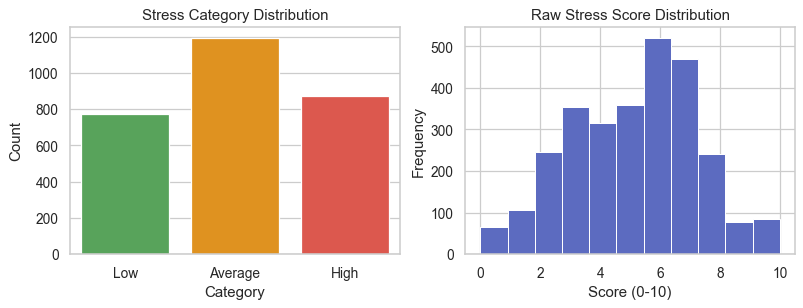

In [10]:
eda.plot_distributions(df, config.TARGET, config.TARGET_CATEGORY, config.CATEGORY_ORDER)

2. **Bivariate Analysis**:
   - Correlation heatmap between features
   - Feature-target relationships
   - Identify multicollinearity issues

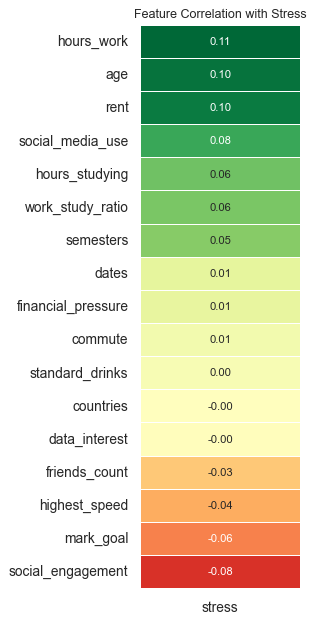

In [11]:
eda.plot_correlation_heatmap(df_eda, config.ALL_NUMERIC, config.TARGET)

3. **Target Variable Analysis**:
   - Class distribution (Low, Average, High stress)
   - Check for class imbalance
   - Visualize stress categories

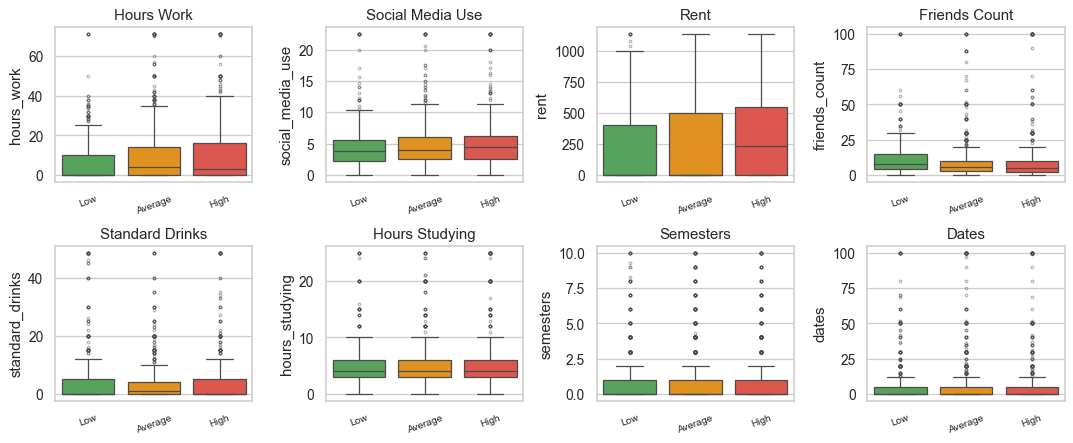

In [12]:
eda.boxplot_key_features(df, config.TARGET_CATEGORY, config.CATEGORY_ORDER)

### **Configure Data Split Ratios**
- **Training Set (75%)**: Used for model learning and parameter estimation
- **Validation Set (10%)**: Used for hyperparameter tuning and model selection
- **Test Set (15%)**: Hold-out set for final unbiased performance evaluation

In [13]:
train_ratio, val_ratio, test_ratio = 0.75, 0.10, 0.15
train_path      = config.DATA_DIR / "train.csv"
validation_path = config.DATA_DIR / "validation.csv"
test_path       = config.DATA_DIR / "test.csv"
required_cols   = config.ALL_NUMERIC + config.ALL_CATS + [config.TARGET_CATEGORY]

if all(p.exists() for p in [train_path, validation_path, test_path]):
    train_df      = pd.read_csv(train_path)[required_cols]
    validation_df = pd.read_csv(validation_path)[required_cols]
    test_df       = pd.read_csv(test_path)[required_cols]
    print("✓ Loaded existing splits")
else:
    X_raw, y_cat = df[config.ALL_NUMERIC + config.ALL_CATS], df[config.TARGET_CATEGORY]
    
    # First split: separate train (75%) from the remaining 25%
    X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y_cat, test_size=1 - train_ratio, random_state=config.SEED, stratify=y_cat)
    # Second split: divide the 25% into val (15%) and test (10%)
    X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=test_ratio / (val_ratio + test_ratio), random_state=config.SEED, stratify=y_temp)

    config.DATA_DIR.mkdir(parents=True, exist_ok=True)
    splits = {"train_df": (X_train, y_train, train_path), "validation_df": (X_val, y_val, validation_path), "test_df": (X_test, y_test, test_path)}
    for name, (X, y, path) in splits.items():
        out = X.assign(**{config.TARGET_CATEGORY: y.values})
        out.to_csv(path, index=False)
        globals()[name] = out
    print("✓ Created new splits")

for label, split in [("Train", train_df), ("Val", validation_df), ("Test", test_df)]:
    dist = split[config.TARGET_CATEGORY].value_counts().reindex(config.CATEGORY_ORDER).to_dict()
    print(f"  {label:5s}: {len(split):4d} rows | {dist}")

✓ Loaded existing splits
  Train: 2131 rows | {'Low': 580, 'Average': 896, 'High': 655}
  Val  :  284 rows | {'Low': 77, 'Average': 119, 'High': 88}
  Test :  427 rows | {'Low': 116, 'Average': 180, 'High': 131}


### **Pipeline Transformers**
Apply preprocessing pipeline (StandardScaler for numeric features, OneHotEncoder for categorical features) to transform data for model training.

In [14]:
X_train_t = pipeliner.fit_transform(train_df[config.ALL_NUMERIC + config.ALL_CATS])
X_val_t   = pipeliner.transform(validation_df[config.ALL_NUMERIC + config.ALL_CATS])
X_test_t  = pipeliner.transform(test_df[config.ALL_NUMERIC + config.ALL_CATS])
print(f"✓ Pipeline transformations applied")
print(f"  Transformed shapes - Train: {X_train_t.shape} | Val: {X_val_t.shape} | Test: {X_test_t.shape}")

# Extract features and targets from splits
X_train = train_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_train = train_df[config.TARGET_CATEGORY]

X_val = validation_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_val = validation_df[config.TARGET_CATEGORY]

X_test = test_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_test = test_df[config.TARGET_CATEGORY]
    

✓ Pipeline transformations applied
  Transformed shapes - Train: (2131, 43) | Val: (284, 43) | Test: (427, 43)


### **Basic Training and Evaluation**

  BASIC MODELS — Training
Trained: Multinomial Logistic Regression
Train F1: 0.4124  Val F1: 0.3717

── Multinomial Logistic Regression — Basic Metrics ──

  Multinomial Logistic Regression  |  F1 (weighted): 35.7%
              precision    recall  f1-score   support

         Low       0.36      0.17      0.23       116
     Average       0.42      0.72      0.53       180
        High       0.36      0.17      0.23       131

    accuracy                           0.40       427
   macro avg       0.38      0.35      0.33       427
weighted avg       0.39      0.40      0.36       427



KeyError: 'accuracy'

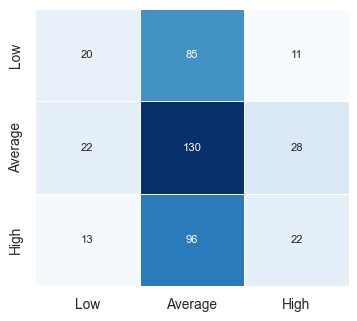

In [15]:
# ── Train basic ───────────────────────────────────────────────────────────────
print("=" * 60)
print("  BASIC MODELS — Training")
print("=" * 60)

basic_models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    GradientBoostingModel(),
    DecisionTreeModel(),
]

basic_reports = {}
for model in basic_models:
    model.train_basic(X_train_t, ycat_train.values, X_val_t, ycat_val.values)

    # ── Per-model metrics ─────────────────────────────────────────────────────
    print(f"\n── {model.get_name()} — Basic Metrics ──")
    preds = {model.get_name(): model.predict_basic(X_test_t)}
    report = evaluator.classification_report_all(ycat_test.values, preds, config.CATEGORY_ORDER)
    evaluator.print_classification_reports(report)
    visualizer.plot_confusion_matrices(report, config.CATEGORY_ORDER)
    model.plot_loss_curve()
    basic_reports.update(report)


In [ ]:

# ── Basic model comparison ────────────────────────────────────────────────────
print("\n── Basic Model Comparison ──")
evaluator.print_score_table(basic_models, "Basic", basic_reports)
visualizer.plot_model_comparison(
    list(basic_reports.keys()),
    [v["f1"] for v in basic_reports.values()],
)

# ── Save basic pickles ────────────────────────────────────────────────────────
config.SAVED_MODELS_BASIC_DIR.mkdir(parents=True, exist_ok=True)
for model in basic_models:
    path = config.SAVED_MODELS_BASIC_DIR / config.MODEL_FILE_MAP[model.get_name()]
    model.save_basic(path)
    print(f"  Saved basic  → {path}")


### **Best Training and Evaluation**


In [ ]:

# ── Train best ────────────────────────────────────────────────────────────────
print("=" * 60)
print("  BEST MODELS — Training")
print("=" * 60)

best_models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    GradientBoostingModel(),
    DecisionTreeModel(),
]

best_reports = {}
for model in best_models:
    model.train_best(X_train_t, ycat_train.values, X_val_t, ycat_val.values)

    # ── Per-model metrics ─────────────────────────────────────────────────────
    print(f"\n── {model.get_name()} — Best Metrics ──")
    preds = {model.get_name(): model.predict_best(X_test_t)}
    report = evaluator.classification_report_all(ycat_test.values, preds, config.CATEGORY_ORDER)
    evaluator.print_classification_reports(report)
    visualizer.plot_confusion_matrices(report, config.CATEGORY_ORDER)
    model.plot_loss_curve()
    best_reports.update(report)


In [ ]:
# ── Best model comparison ─────────────────────────────────────────────────────
print("\n── Best Model Comparison ──")
evaluator.print_score_table(best_models, "Best", best_reports)
visualizer.plot_model_comparison(
    list(best_reports.keys()),
    [v["f1"] for v in best_reports.values()],
)

# ── Save best pickles ─────────────────────────────────────────────────────────
config.SAVED_MODELS_BEST_DIR.mkdir(parents=True, exist_ok=True)
for model in best_models:
    path = config.SAVED_MODELS_BEST_DIR / config.MODEL_FILE_MAP[model.get_name()]
    model.save_best(path)
    print(f"  Saved best   → {path}")


### **Improving Model Performance**

In [ ]:
print("=" * 55)
print("  FEATURES USED")
print("=" * 55)

print(f"\nNumeric ({len(config.NUMERIC_COLS)}):")
for f in config.NUMERIC_COLS:
    print(f"  • {f}")

print(f"\nCategorical ({len(config.CATEGORICAL_COLS)}):")
for f in config.CATEGORICAL_COLS:
    print(f"  • {f}")

print(f"\nDerived ({len(config.DERIVED_COLS)}):")
for f in config.DERIVED_COLS:
    print(f"  • {f}")

print(f"\nTarget: {config.TARGET}  →  {config.TARGET_CATEGORY}  {config.CATEGORY_ORDER}")
print(f"\nTotal input features: {len(config.ALL_NUMERIC) + len(config.ALL_CATS)}")
print("=" * 55)

# ── Feature correlation with target (stress) ──────────────────────────────────
corr = (
    df_eda[config.ALL_NUMERIC + config.ALL_CATS + [config.TARGET]]
    .corr()[config.TARGET]
    .drop(config.TARGET)
    .sort_values(key=abs, ascending=False)
)

print("\n" + "=" * 48)
print("  FEATURE CORRELATION WITH TARGET (stress)")
print("=" * 48)
print(f"  {'Feature':<28} {'Corr':>7}")
print(f"  {'─'*28}  {'─'*7}")
for feat, val in corr.items():
    bar = "█" * int(abs(val) * 20)
    sign = "+" if val >= 0 else "-"
    print(f"  {feat:<28} {val:+.4f}  {sign}{bar}")
print("=" * 48)


### **Refined Model — Low-Correlation Features Removed**
Features with near-zero correlation to the target are dropped to reduce noise and improve generalisation.

**Removed features** (|corr| < 0.05):
`highest_speed`, `friends_count`, `dates`, `commute`, `standard_drinks`, `data_interest`, `countries`, `relationship_status`, `lecture_mode`, `drug_use_ans`, `study_type`, `learner_style`, `financial_pressure`

In [ ]:

# ── Define refined feature sets (drop low-correlation features) ───────────────
DROP_NUMERIC     = {"highest_speed", "friends_count", "dates", "commute",
                    "standard_drinks", "data_interest", "countries"}
DROP_CATEGORICAL = {"relationship_status", "lecture_mode", "drug_use_ans",
                    "study_type", "learner_style"}
DROP_DERIVED     = {"financial_pressure"}

R_NUMERIC_COLS = [f for f in config.NUMERIC_COLS     if f not in DROP_NUMERIC]
R_CAT_COLS     = [f for f in config.CATEGORICAL_COLS if f not in DROP_CATEGORICAL]
R_DERIVED_COLS = [f for f in config.DERIVED_COLS     if f not in DROP_DERIVED]
R_ALL_NUMERIC  = R_NUMERIC_COLS + R_DERIVED_COLS
R_ALL_CATS     = R_CAT_COLS

print(f"Numeric     : {len(config.NUMERIC_COLS)} → {len(R_NUMERIC_COLS)}   {R_NUMERIC_COLS}")
print(f"Categorical : {len(config.CATEGORICAL_COLS)} → {len(R_CAT_COLS)}   {R_CAT_COLS}")
print(f"Derived     : {len(config.DERIVED_COLS)} → {len(R_DERIVED_COLS)}   {R_DERIVED_COLS}")
print(f"\nTotal features: {len(config.ALL_NUMERIC)+len(config.ALL_CATS)} → {len(R_ALL_NUMERIC)+len(R_ALL_CATS)}")


In [ ]:
# ── Remove outliers using IQR on refined numeric features ─────────────────────
# Bounds are fit on train only to prevent data leakage into val/test
print("Shapes BEFORE outlier removal:")
print(f"  Train : {train_df.shape}")
print(f"  Val   : {validation_df.shape}")
print(f"  Test  : {test_df.shape}")

iqr_bounds = {}
for col in R_NUMERIC_COLS:
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    iqr = q3 - q1
    iqr_bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

def apply_iqr_filter(df):
    mask = pd.Series(True, index=df.index)
    for col, (lo, hi) in iqr_bounds.items():
        mask &= df[col].between(lo, hi)
    return df[mask].reset_index(drop=True)

r_train_df = apply_iqr_filter(train_df)
r_val_df   = apply_iqr_filter(validation_df)
r_test_df  = apply_iqr_filter(test_df)

rycat_train = r_train_df[config.TARGET_CATEGORY]
rycat_val   = r_val_df[config.TARGET_CATEGORY]
rycat_test  = r_test_df[config.TARGET_CATEGORY]

print("\nShapes AFTER outlier removal:")
print(f"  Train : {r_train_df.shape}  (removed {len(train_df) - len(r_train_df)} rows)")
print(f"  Val   : {r_val_df.shape}  (removed {len(validation_df) - len(r_val_df)} rows)")
print(f"  Test  : {r_test_df.shape}  (removed {len(test_df) - len(r_test_df)} rows)")


In [ ]:

# ── Rebuild pipeline with refined features on outlier-filtered splits ─────────
r_pipeliner = Pipeliner(R_ALL_NUMERIC, R_ALL_CATS)

rX_train_t = r_pipeliner.fit_transform(r_train_df[R_ALL_NUMERIC + R_ALL_CATS])
rX_val_t   = r_pipeliner.transform(r_val_df[R_ALL_NUMERIC + R_ALL_CATS])
rX_test_t  = r_pipeliner.transform(r_test_df[R_ALL_NUMERIC + R_ALL_CATS])

print(f"✓ Refined pipeline built")
print(f"  Shapes — Train: {rX_train_t.shape} | Val: {rX_val_t.shape} | Test: {rX_test_t.shape}")


#### Basic Models — Refined Features

In [ ]:

# ── Train basic (refined) ─────────────────────────────────────────────────────
print("=" * 60)
print("  REFINED BASIC MODELS — Training")
print("=" * 60)

r_basic_models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    GradientBoostingModel(),
    DecisionTreeModel(),
]

r_basic_reports = {}
for model in r_basic_models:
    model.train_basic(rX_train_t, rycat_train.values, rX_val_t, rycat_val.values)

    print(f"\n── {model.get_name()} — Refined Basic Metrics ──")
    preds = {model.get_name(): model.predict_basic(rX_test_t)}
    report = evaluator.classification_report_all(rycat_test.values, preds, config.CATEGORY_ORDER)
    evaluator.print_classification_reports(report)
    visualizer.plot_confusion_matrices(report, config.CATEGORY_ORDER)
    model.plot_loss_curve()
    r_basic_reports.update(report)

print("\n── Refined Basic Model Comparison ──")
evaluator.print_score_table(r_basic_models, "Refined Basic", r_basic_reports)
visualizer.plot_model_comparison(
    list(r_basic_reports.keys()),
    [v["f1"] for v in r_basic_reports.values()],
)


#### Best Models — Refined Features

In [ ]:

# ── Train best (refined) ──────────────────────────────────────────────────────
print("=" * 60)
print("  REFINED BEST MODELS — Training")
print("=" * 60)

r_best_models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    GradientBoostingModel(),
    DecisionTreeModel(),
]

r_best_reports = {}
for model in r_best_models:
    model.train_best(rX_train_t, rycat_train.values, rX_val_t, rycat_val.values)

    print(f"\n── {model.get_name()} — Refined Best Metrics ──")
    preds = {model.get_name(): model.predict_best(rX_test_t)}
    report = evaluator.classification_report_all(rycat_test.values, preds, config.CATEGORY_ORDER)
    evaluator.print_classification_reports(report)
    visualizer.plot_confusion_matrices(report, config.CATEGORY_ORDER)
    model.plot_loss_curve()
    r_best_reports.update(report)

print("\n── Refined Best Model Comparison ──")
evaluator.print_score_table(r_best_models, "Refined Best", r_best_reports)
visualizer.plot_model_comparison(
    list(r_best_reports.keys()),
    [v["f1"] for v in r_best_reports.values()],
)
